# Canadian Credit Relative Value — walkthrough

Finds Canadian investment-grade corporate bonds trading cheap or rich versus their fundamentals and turns the strongest signal into a CS01-neutral long/short trade.

Data comes from free sources instead of Bloomberg (iShares XCB month-end holdings, Bank of Canada benchmark yields, SEC EDGAR fundamentals and AIF credit ratings); see `bloomberg_adapter/PLAN.md`. Rebuild the inputs with `uv run python -m bloomberg_adapter.build_panel`.

**Sections:** 1. Data · 2. Spreads over time · 3. Coupon, age and call effects · 4. Spread curves · 5. Fundamental regression · 6. Backtest · 7. The trade · 8. Limitations

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.load_data import load_bonds, load_goc_yields
from src import curves, regression, backtest, trade

%matplotlib inline
pd.set_option("display.precision", 2)
pd.set_option("display.width", 140)

## 1. Data

One row per bond per month-end. The universe is CAD senior unsecured bonds from four sectors, 2–12 years to maturity, after excluding bank NVCC sub debt, hybrids and floating-rate notes.

In [2]:
bonds = load_bonds()
print(f"{len(bonds):,} bond-months, {bonds['isin'].nunique()} bonds, {bonds['issuer'].nunique()} issuers, "
      f"{bonds['date'].nunique()} month-ends ({bonds['date'].min():%b %Y} – {bonds['date'].max():%b %Y})")
summary = bonds.groupby("sector").agg(
    bonds=("isin", "nunique"), issuers=("issuer", "nunique"),
    median_spread_bp=("g_spread", "median"), rated_share=("rating", lambda s: s.notna().mean()),
    leverage_share=("leverage", lambda s: s.notna().mean()))
summary

5,873 bond-months, 233 bonds, 15 issuers, 45 month-ends (Jan 2023 – Sep 2026)


,bonds,issuers,median_spread_bp,rated_share,leverage_share
sector,,,,,
Banks,103,6,74.28,0.87,0.00
Pipelines,47,3,117.83,1.00,1.00
Telecom,49,3,114.62,1.00,1.00
Utilities,34,3,92.54,0.15,0.45


## 2. Spreads over time

Median G-spread by sector each month. All four sectors tightened steadily from 2023, so the sample is one long rally — worth remembering when reading the backtest.

GoC 5y yield: 3.04% → 3.69%


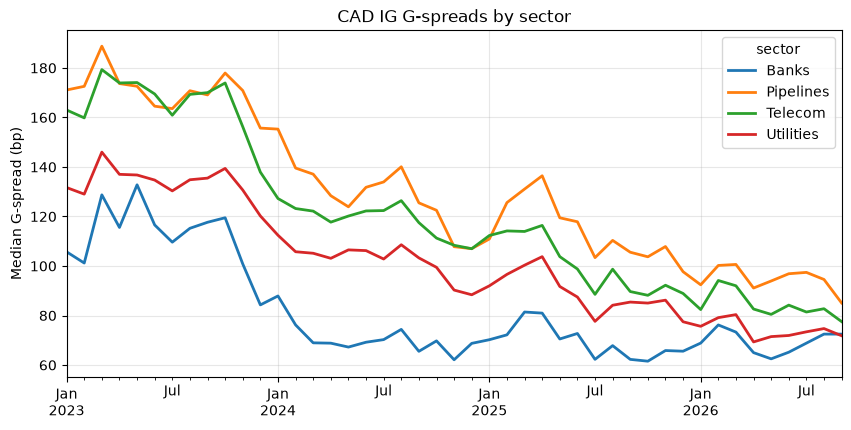

In [3]:
med = bonds.groupby(["date", "sector"])["g_spread"].median().unstack()
ax = med.plot(figsize=(10, 4.5), lw=2)
ax.set_ylabel("Median G-spread (bp)"); ax.set_xlabel(""); ax.grid(alpha=0.3)
ax.set_title("CAD IG G-spreads by sector")
goc = load_goc_yields()
print("GoC 5y yield: {:.2f}% → {:.2f}%".format(goc[5.0].iloc[0], goc[5.0].iloc[-1]))

## 3. Coupon, age and call effects

Within the same issuer — same credit risk — bonds priced above par trade wider than par bonds, older bonds trade wider than new ones, and bank notes callable a year early trade wider than bullets. These are structural (discount-bond tax treatment, off-the-run liquidity, call/extension risk), not mispricings, so the curves remove them before looking for rich/cheap bonds.

Latest month: a bond at 110 trades ~22bp wider than a par bond of the same issuer.


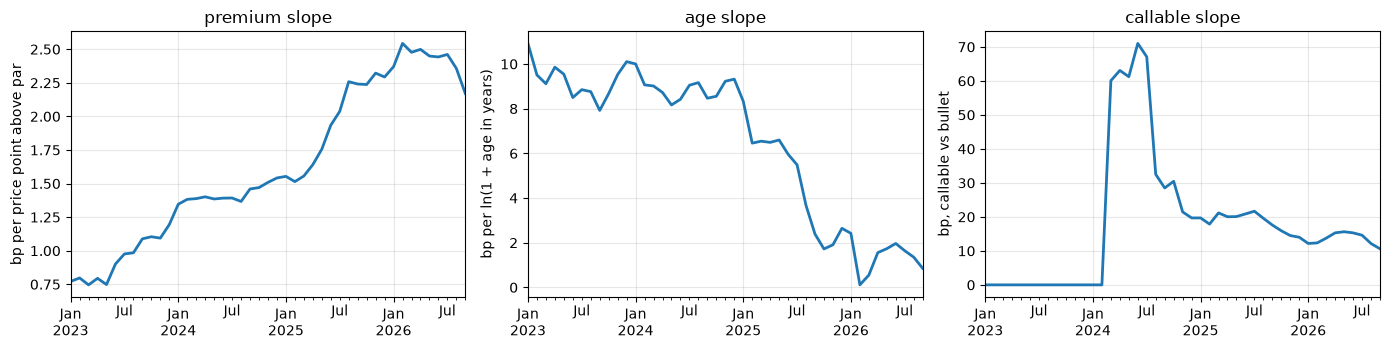

In [4]:
sig, params = curves.add_curve_signals(bonds)
slopes = sig.groupby("date")[["premium_slope", "age_slope", "callable_slope"]].first()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, label in zip(axes, slopes.columns, ["bp per price point above par", "bp per ln(1 + age in years)", "bp, callable vs bullet"]):
    slopes[col].plot(ax=ax, lw=2); ax.set_title(col.replace("_", " ")); ax.set_ylabel(label); ax.grid(alpha=0.3); ax.set_xlabel("")
fig.tight_layout()
latest = sig[sig["date"] == sig["date"].max()]
print(f"Latest month: a bond at 110 trades ~{10 * latest['premium_slope'].iloc[0]:.0f}bp wider than a par bond of the same issuer.")

## 4. Spread curves

Each month: par-equivalent spread = a + b·ln(years to workout), per issuer (4+ bonds) and per sector. Each bond is judged against the curve fitted on its *other* bonds (leave-one-out), and residuals become robust z-scores. Circled bonds are beyond ±1.5σ on both curves.

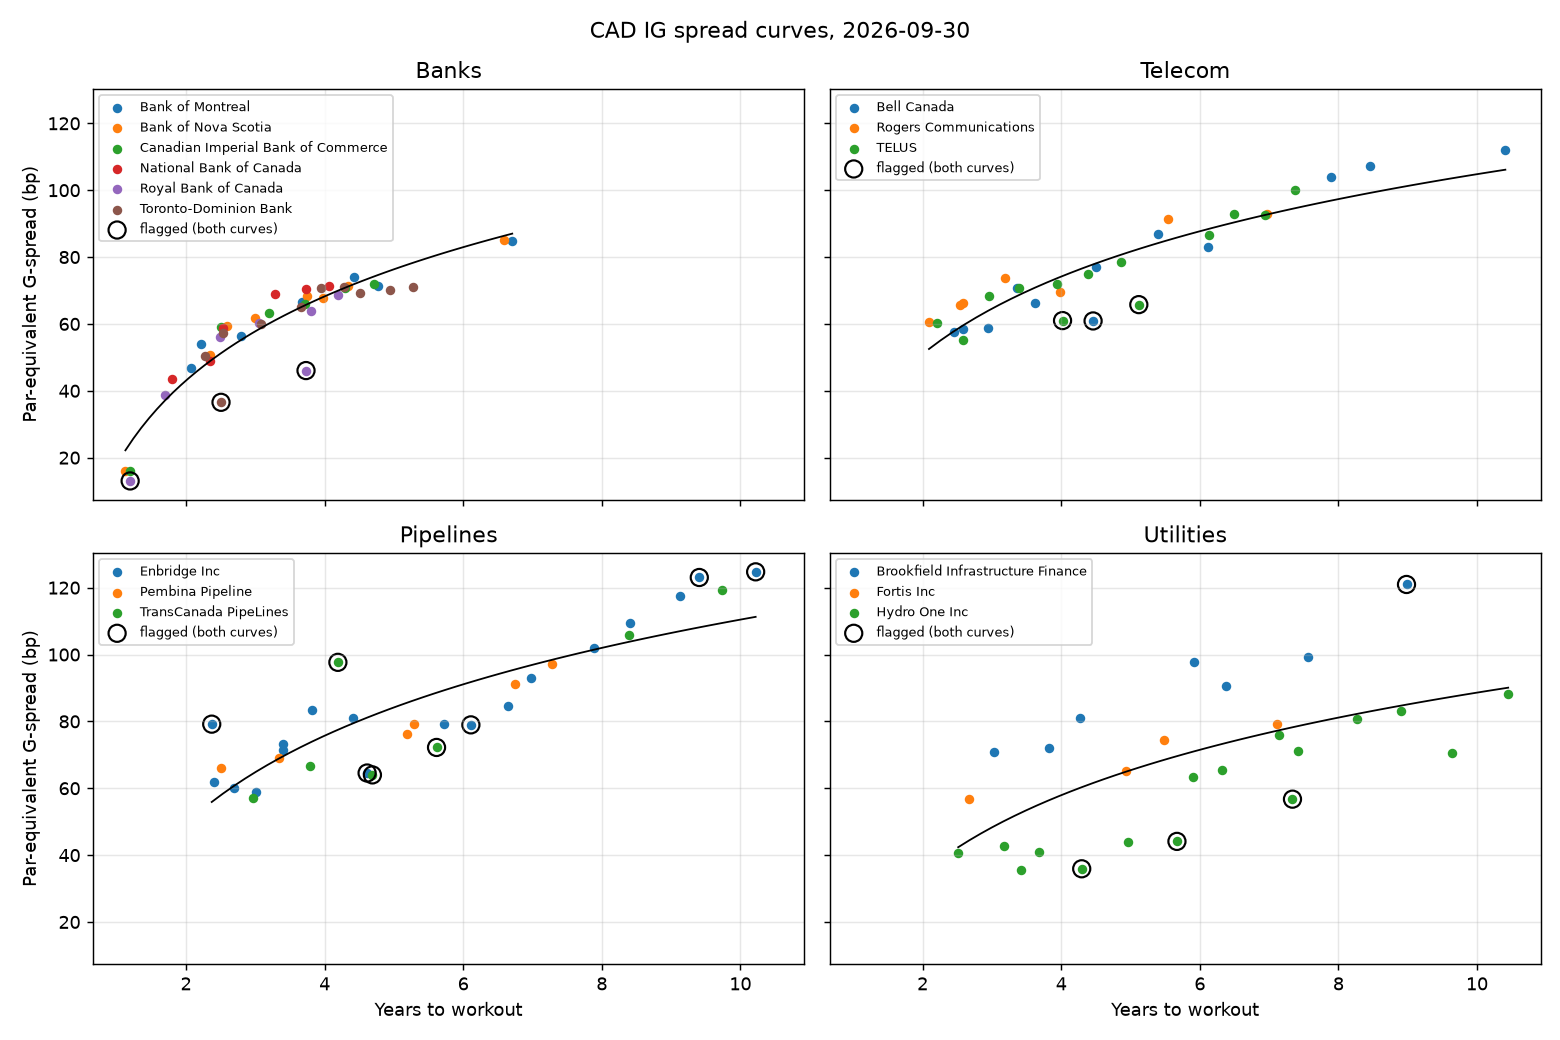

Flagged on both curves: 14.3 bonds per month on average


In [5]:
date = sig["date"].max()
path = curves.plot_sector_curves(sig, params, date, curves.FIGURES / f"sector_curves_{date:%Y-%m}.png")
display(Image(filename=str(path)))
flagged = (sig["curve_signal"] != "").groupby(sig["date"]).sum()
print(f"Flagged on both curves: {flagged.mean():.1f} bonds per month on average")

## 5. Fundamental regression

G-spread on ln(years to workout), rating, leverage and coverage (non-banks), ln(size), price premium, ln(age), a callable flag, sector and bail-in dummies. The monthly cross-section is the point-in-time signal; the pooled panel (month fixed effects, issuer-clustered errors) gives the coefficient table.

In [6]:
out, df, stats = regression.add_regression_signals(bonds)
pooled = regression.fit_pooled(df)
print(f"Regression sample: {len(df):,} bond-months, {df['issuer'].nunique()} issuers "
      f"(missing ratings exclude: {', '.join(sorted(set(bonds['issuer']) - set(df['issuer'])))})")
print(f"Monthly R²: median {stats['r2'].median():.2f}, range {stats['r2'].min():.2f}–{stats['r2'].max():.2f}; pooled R² {pooled.rsquared:.2f}")
keep = regression.TERMS + [p for p in pooled.params.index if p.startswith("C(sector") or p == "bail_in"]
pd.DataFrame({"coef": pooled.params[keep], "se (issuer-clustered)": pooled.bse[keep], "p": pooled.pvalues[keep]})

Regression sample: 4,708 bond-months, 12 issuers (missing ratings exclude: Brookfield Infrastructure Finance, Hydro One Inc, National Bank of Canada)
Monthly R²: median 0.91, range 0.87–0.96; pooled R² 0.89


,coef,se (issuer-clustered),p
log_t,52.47,2.63,9.96e-89
rating,5.82,1.63,3.56e-04
leverage_nb,1.58,1.62,3.30e-01
coverage_nb,-0.17,0.93,8.59e-01
log_size,-4.04,2.10,5.39e-02
premium,1.49,0.16,3.62e-20
log_age,7.26,2.20,9.65e-04
callable,20.48,4.09,5.37e-07
"C(sector, Treatment('Utilities'))[T.Banks]",0.30,12.11,9.80e-01
"C(sector, Treatment('Utilities'))[T.Pipelines]",20.11,3.05,4.35e-11


Rating, maturity, size, premium, age, callable and bail-in are significant and stable. **Leverage and coverage are not**: with only seven non-bank issuers, rating and sector already absorb what they'd explain. The high R² is mostly issuer-level sorting.

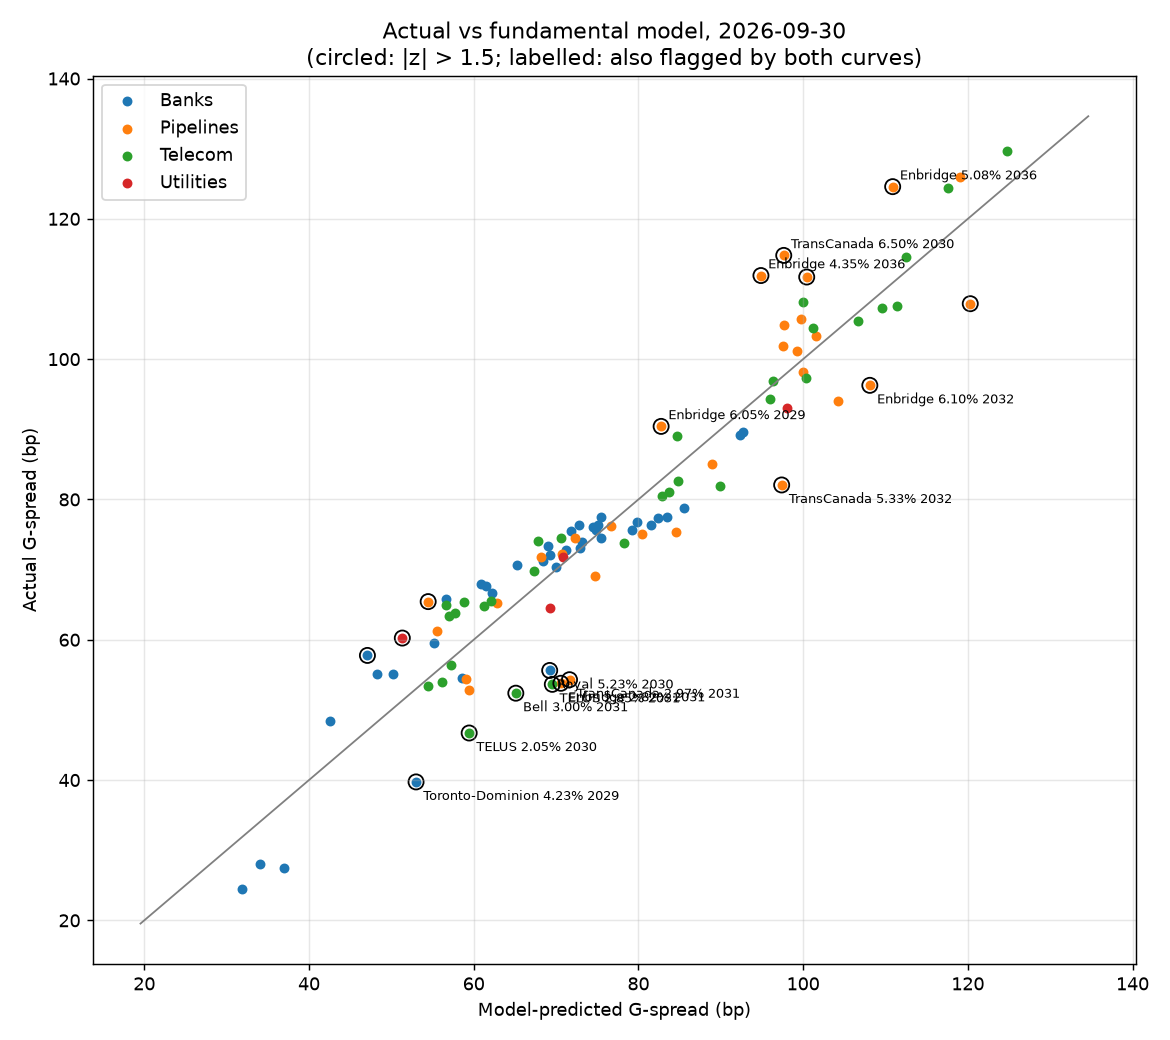

In [7]:
path = regression.plot_actual_vs_model(out, date, regression.FIGURES / f"actual_vs_model_{date:%Y-%m}.png")
display(Image(filename=str(path)))

## 6. Backtest

Using only each month's point-in-time signal: does today's residual predict the bond's **excess** spread change over the next 1–3 months (own change − sector average, net of roll-down)?

In [8]:
bt = backtest.add_forward_changes(out, stats)
fm = pd.DataFrame([{"signal": name, "h": h, **backtest.fama_macbeth(bt, col, f"fwd_{h}", lags=h)}
                   for name, col in backtest.SIGNALS.items() for h in backtest.HORIZONS])
fm

,signal,h,slope,t,months,share_negative
0,reg,1,-0.05,-6.40,44,0.77
1,reg,2,-0.07,-5.99,43,0.86
2,reg,3,-0.10,-5.27,42,0.88
3,issuer,1,-0.03,-3.50,44,0.70
4,issuer,2,-0.04,-2.89,43,0.70
5,issuer,3,-0.06,-2.65,42,0.74
6,sector,1,-0.03,-4.01,44,0.73
7,sector,2,-0.05,-3.69,43,0.77
8,sector,3,-0.06,-3.62,42,0.76


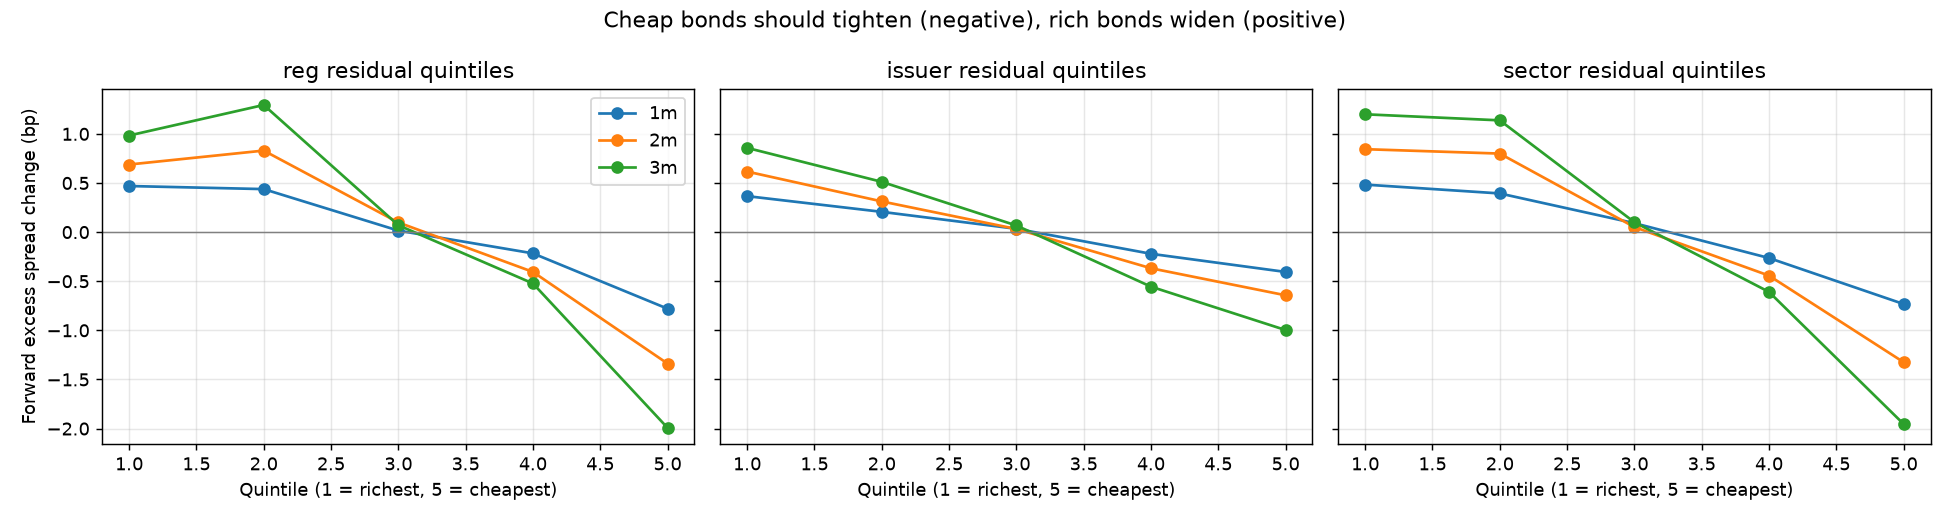

Cheapest − richest quintile, 3-month excess change by year (bp): {2023: -1.22, 2024: -4.17, 2025: -2.48, 2026: -4.77}


In [9]:
tables = {name: backtest.quintile_table(bt, col.replace("_resid", "_z")) for name, col in backtest.SIGNALS.items()}
display(Image(filename=str(backtest.plot_quintiles(tables, backtest.FIGURES / "backtest_quintiles.png"))))
years = {y: round(float(backtest.quintile_table(g, "reg_z").loc["5-1", "fwd_3"]), 2) for y, g in bt.groupby(bt["date"].dt.year)}
print("Cheapest − richest quintile, 3-month excess change by year (bp):", years)

In [10]:
per_bond, pooled_ar = backtest.half_lives(bt, "reg_resid")
hh = backtest.horizon_half_life(bt, "reg_resid", 3)
pd.Series({
    "per-bond AR(1) half-life, raw (biased short)": per_bond["half_life"].median(),
    "per-bond AR(1) half-life, bias-corrected": per_bond["half_life_corrected"].median(),
    "pooled AR(1) half-life": pooled_ar["half_life_raw"],
    "3-month horizon half-life (preferred)": hh["half_life"],
}, name="months").round(1)

per-bond AR(1) half-life, raw (biased short)     3.0
per-bond AR(1) half-life, bias-corrected         7.8
pooled AR(1) half-life                           8.8
3-month horizon half-life (preferred)           11.7
Name: months, dtype: float64

The signal is real and stable but slow: about a sixth of a residual is gone after three months, mostly through the bond's own spread moving. A few bp per quarter is about one bid/ask, so a trade needs a large gap, a holding period of months and positive carry.

## 7. The trade

Candidates must be in the same sector and call structure, with workouts within 1.5 years, prices within 8 points and issue vintages within 5 years, so the pair differs in credit pricing rather than structure. Legs are sized CS01-neutral; the expected P&L over 12 months (≈ one half-life) is convergence + carry + roll-down − bid/ask.

In [11]:
goc_m = load_goc_yields()
funding = float(goc_m.loc[goc_m.index.to_period("M") == date.to_period("M"), 2.0].iloc[0])
pairs = trade.candidate_pairs(out, date)
evaluated = [trade.evaluate(r, out, params, funding, 12) for _, r in pairs.head(12).iterrows()]
pd.DataFrame([{"long": e["long"].name, "short": e["short"].name, "gap_bp": e["gap_bp"], "carry_bp_yr": e["carry_bp_yr"],
               "roll_bp": e["roll_bp"], "expected_12m_bp": e["expected_bp"], "stop_bp": e["stop_bp"]} for e in evaluated])

,long,short,gap_bp,carry_bp_yr,roll_bp,expected_12m_bp,stop_bp
0,Bank of Montreal 4.54% Dec-2028,Toronto-Dominion Bank 4.23% Apr-2029,29.00,9.62,1.68,22.50,25.39
1,Toronto-Dominion Bank 4.68% Jan-2029,Royal Bank of Canada 5.23% Jun-2030,26.47,5.20,7.30,22.37,20.91
2,Toronto-Dominion Bank 4.68% Jan-2029,Toronto-Dominion Bank 4.23% Apr-2029,24.44,7.92,2.24,18.97,25.73
3,Bank of Nova Scotia 4.68% Feb-2029,Royal Bank of Canada 5.23% Jun-2030,24.19,4.73,10.00,23.41,19.24
4,Bank of Nova Scotia 4.68% Feb-2029,Toronto-Dominion Bank 4.23% Apr-2029,22.16,7.46,4.93,20.01,26.26
5,Rogers Communications 3.75% Apr-2029,TELUS 2.05% Oct-2030,21.75,11.94,4.73,24.07,28.17
6,Pembina Pipeline 3.62% Apr-2029,TransCanada PipeLines 3.00% Sep-2029,21.31,7.93,-5.15,9.94,30.41
7,Rogers Communications 3.25% May-2029,TELUS 2.05% Oct-2030,21.30,10.72,4.43,22.32,25.09
8,Royal Bank of Canada 3.83% Mar-2030,Canadian Imperial Bank of Commerce 3.65% Dec-2028,20.90,6.18,-44.95,-31.82,35.76
9,Bell Canada 4.55% Feb-2030,Bell Canada 3.00% Mar-2031,20.63,9.60,3.96,20.37,20.05


Bank pairs score well but the data can't tell covered, deposit-note and bail-in programs apart, so the pitch uses the cleanest non-bank pair.

Long  Pembina Pipeline 3.62% Apr-2029: price 98.92, G-spread 65bp, residual +14bp (z +1.8), C$10.0mm
Short TransCanada PipeLines 3.00% Sep-2029: price 97.24, G-spread 53bp, residual -8bp (z -1.0), C$8.61mm
CS01 C$2,346/bp per leg
12m expected +9.9bp (C$+23,321) = convergence +11.2 + carry +7.9 + roll -5.2 − costs 4.0
Entry 13bp → target 1bp, stop 43bp
Leverage: long 3.16x (Dec-2023) → 3.05x (Dec-2025); short 5.53x (Dec-2023) → 4.43x (Dec-2025)


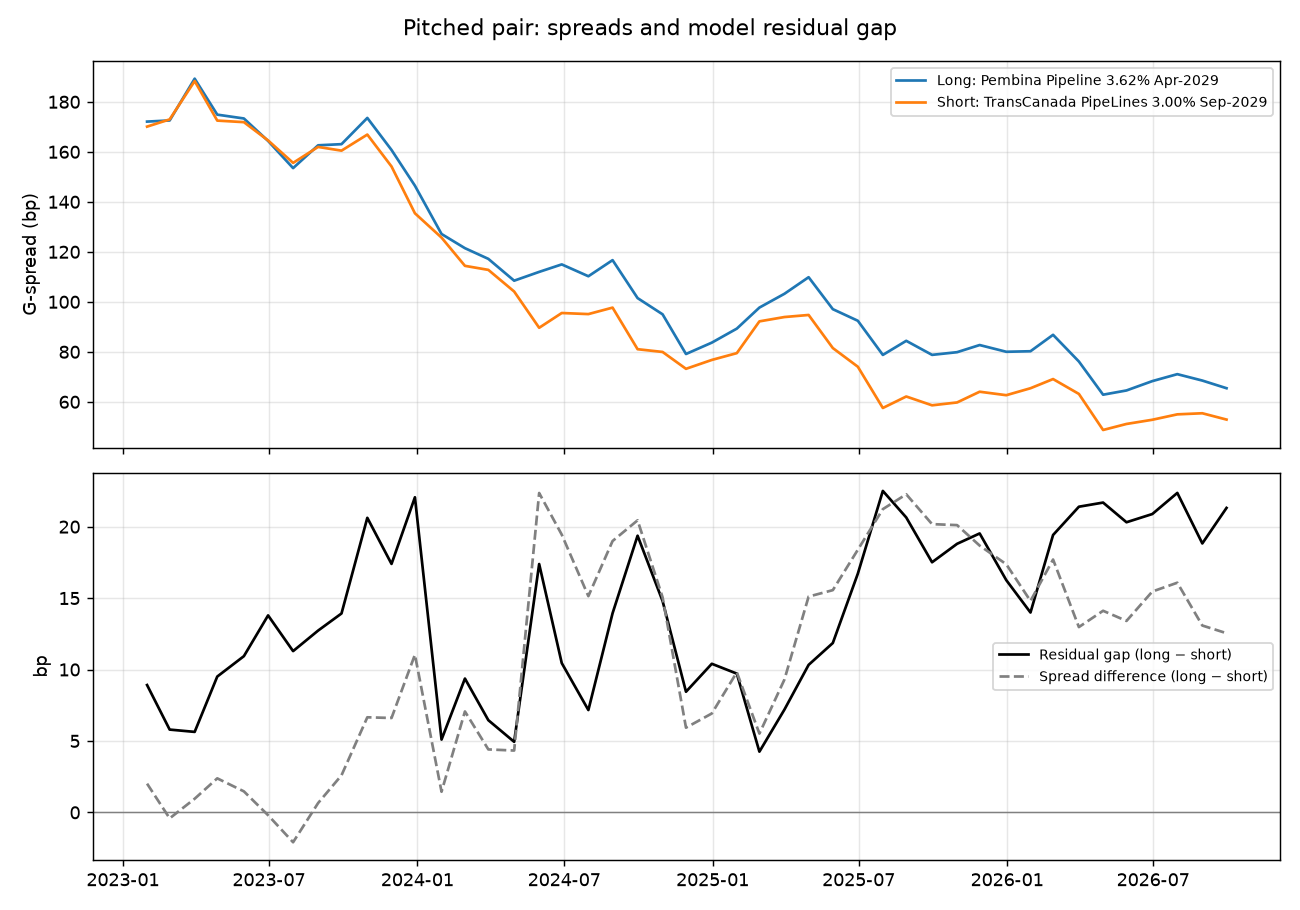

In [12]:
pick = next(e for e in evaluated if e["long"].isin == "CA70632ZAM38" and e["short"].isin == "CA89353ZCE66")
L, S = pick["long"], pick["short"]
print(f"Long  {L.name}: price {L.price:.2f}, G-spread {L.g_spread:.0f}bp, residual {L.resid:+.0f}bp (z {L.z:+.1f}), C$10.0mm")
print(f"Short {S.name}: price {S.price:.2f}, G-spread {S.g_spread:.0f}bp, residual {S.resid:+.0f}bp (z {S.z:+.1f}), C${pick['short_face'] / 1e6:.2f}mm")
print(f"CS01 C${pick['cs01']:,.0f}/bp per leg")
print(f"12m expected {pick['expected_bp']:+.1f}bp (C${pick['expected_cad']:+,.0f}) = convergence {pick['convergence_bp']:+.1f} "
      f"+ carry {pick['carry_bp_yr']:+.1f} + roll {pick['roll_bp']:+.1f} − costs {pick['cost_bp']:.1f}")
print(f"Entry {pick['entry_diff']:.0f}bp → target {pick['target_diff']:.0f}bp, stop {pick['stop_diff']:.0f}bp")
print(f"Leverage: long {pick['leverage']['long']}; short {pick['leverage']['short']}")
display(Image(filename=str(trade.plot_pair(pick, trade.FIGURES / "pair_history.png"))))

**Thesis:** Pembina is much less levered than TCPL (≈3.1x vs 4.4x) with a similar rating, yet trades 13bp wider among same-vintage pipeline bonds. **Risks:** the gap has held ~20bp for a year as TC Energy deleveraged after the South Bow spin-off; Pembina is the smaller issuer and has no Moody's rating; prices are evaluated, not traded.

## 8. Limitations

- **Evaluated prices.** XCB holdings use vendor model prices, which smooth gaps and can flatter mean reversion. Check pitched bonds on CIRO trade data.
- **Few issuers.** 12 issuers in the regression (7 non-banks), so fundamental coefficients are weakly identified; leverage and coverage add nothing beyond rating and sector here.
- **Missing inputs.** Ratings for Hydro One, BIP and National Bank and amounts outstanding are hand-entered and not yet filled; ETF holding size stands in for issue size.
- **One regime.** 45 month-ends of mostly tightening spreads; mean reversion may behave differently in a selloff.
- **Structure inferred, not labelled.** Callables and FRNs are detected from ETF duration; bank covered/deposit/bail-in programs can't be told apart.
- **Small look-ahead.** Structure classification uses each bond's full history; prices, ratings and fundamentals are point-in-time.